In [2]:
import ROOT
from ROOT import RooFit, RooRealVar, RooDataSet, RooArgList, RooAddPdf, RooGaussian, RooFormulaVar, RooSimultaneous, RooCategory
from ROOT.RooFit import Extended, FitOptions, Save, PrintEvalErrors, PrintLevel, Bins, FitGauss,    NumCPU, Strategy, Offset
import glob
import ctypes
import os
import argparse

ROOT.gROOT.LoadMacro('/home/jykim/workspace/DRAW_and_FITTING/main/FITTING/Belle2Style.C')
ROOT.SetBelle2Style()

Welcome to JupyROOT 6.26/04

Applying BELLE2 style settings...


In [85]:
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC16rd/MC16rd_pre_test_250609_v2_vg_nodelM"
cm_elements = ["16rd_vg_proc_4S_Budstau", "16rd_vg_proc_4S_ccbar"]
BDT_cut = 0.65
tree_name = "antiKstar"
file_list = []
for element in cm_elements:
    #pattern = f"{base_path}/{element}/{tree_name}/{args.train}/skimhad/*.BCS.root"
    #pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/*.BCS.root"
    #pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/new_FOM/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/bdt_test_v0/{BDT_cut}/*.BCS.root"
    file_list += glob.glob(pattern)
mychain = ROOT.TChain(tree_name)
for i in file_list:
    mychain.Add(i)
print(file_list)
print(f"Numer of files: {len(file_list)}")

# Define variable and its range
fit_variable = "D0_M"
fit_var_name = "M(#bar{K}^{*0}#gamma) [GeV/c^{2}]"
fit_range = (1.68, 2.05)

charge_var = "Pis_charge"
cuts = "D0_M>0"

['/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC16rd/MC16rd_pre_test_250609_v2_vg_nodelM/16rd_vg_proc_4S_Budstau/antiKstar/bdt_test_v0/0.65/Budstau.BCS.root', '/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC16rd/MC16rd_pre_test_250609_v2_vg_nodelM/16rd_vg_proc_4S_ccbar/antiKstar/bdt_test_v0/0.65/ccbar.BCS.root']
Numer of files: 2


In [86]:
x = ROOT.RooRealVar(fit_variable, fit_var_name, fit_range[0], fit_range[1])
# x.setBins(200)
# Pis_charge = ROOT.RooRealVar(charge_var, charge_var, -1, 1)


full_var_set = ROOT.RooArgSet(x)

#before_data = ROOT.RooDataSet("data","", mychain, ROOT.RooArgSet(x,Pip_charge,Dp_CMS_cosTheta), cuts_Dp)
before_data = ROOT.RooDataSet("data", "", mychain, full_var_set, cuts)

w_1 = ROOT.RooRealVar('w_1', 'w', 0,1)
#scale = 427.87/1000
#scale = 1/4
scale = 1
#scale = (1/4)*(427.87+54.3)/427.87
w_1.setVal(scale)
before_data.addColumn(w_1)
data = ROOT.RooDataSet(before_data.GetName(), before_data.GetTitle(),before_data, before_data.get(), '' ,  'w_1')

# scale = 1/4
# scale = 1
# w_scaled = ROOT.RooFormulaVar("w_scaled", "Scaled Weight", f"{scale}")
# before_data.addColumn(w_scaled)

# data = ROOT.RooDataSet("data_weighted", "Weighted Data", before_data, before_data.get(), "", "w_scaled")

In [87]:
N_total = data.sumEntries()

In [88]:
f = ROOT.TFile.Open("/home/jykim/workspace/DRAW_and_FITTING/main/FITTING/antiKstargamma/MC15rd/antiKstarg_MC15rd_Vg_fitresult_D0M.root")
result_object = ROOT.gDirectory.Get("antiKstarg")
f.Close()

result_object.Print("v")

fit_args = result_object.floatParsFinal()

x_sig_alpha= ROOT.RooRealVar("x_sig_alpha", "",  fit_args.at(0).getVal()) 
x_sig_mean = ROOT.RooRealVar("x_sig_mean", "",  fit_args.at(1).getVal()) 
# x_sig_mean = ROOT.RooRealVar("x_sig_mean", "mean of gaussians", 1.863,1.86, 1.88)

x_sig_n_CB = ROOT.RooRealVar("x_sig_n_CB", "",  fit_args.at(2).getVal()) 
x_sig_sig1frac = ROOT.RooRealVar("x_sig_sig1frac", "",  fit_args.at(3).getVal()) 
x_sig_sigma1 = ROOT.RooRealVar("x_sig_sigma1", "",  fit_args.at(4).getVal()) 
x_sig_sigma2 = ROOT.RooRealVar("x_sig_sigma2", "",  fit_args.at(5).getVal()) 


  RooFitResult: minimized FCN value: -12320.8, estimated distance to minimum: 0.0701065
                covariance matrix quality: Full matrix, but forced positive-definite
                Status : MINIMIZE=0 HESSE=0 

    Floating Parameter  InitialValue    FinalValue +/-  Error     GblCorr.
  --------------------  ------------  --------------------------  --------
                 alpha    5.0000e-01    6.9389e-01 +/-  1.35e-01  <none>
                  mean    1.8600e+00    1.8633e+00 +/-  3.57e-04  <none>
                  n_CB    5.0000e+00    1.9998e+01 +/-  1.45e+01  <none>
              sig1frac    5.0000e-01    1.3417e-01 +/-  5.68e-02  <none>
                sigma1    3.0000e-02    2.2200e-02 +/-  2.09e-03  <none>
                sigma2    2.0000e-02    1.2133e-02 +/-  9.37e-04  <none>



In [89]:
f = ROOT.TFile.Open("/home/jykim/workspace/DRAW_and_FITTING/main/FITTING/antiKstargamma/MC15rd/antiKstarg_MC15rd_Vpi0_fitresult.root")
result_object2 = ROOT.gDirectory.Get("antiKstarg")
f.Close()

result_object2.Print("v")

fit_args2 = result_object2.floatParsFinal()

#V pi0
x_bkg1_alphaL = ROOT.RooRealVar("x_bkg1_alphaL", "",  fit_args2.at(0).getVal()) 
x_bkg1_alphaR = ROOT.RooRealVar("x_bkg1_alphaR", "",  fit_args2.at(1).getVal()) 

x_bkg1_mean = ROOT.RooRealVar("x_bkg1_mean", "",  fit_args2.at(2).getVal()) 
# x_bkg1_mean = ROOT.RooRealVar("x_bkg1_mean", "",  fit_args2.at(2).getVal(), 1.80, 1.86) 

x_bkg1_nL = ROOT.RooRealVar("x_bkg1_nL", "",  fit_args2.at(3).getVal()) 
x_bkg1_nR = ROOT.RooRealVar("x_bkg1_nR", "",  fit_args2.at(4).getVal()) 

x_bkg1_sigmaL = ROOT.RooRealVar("x_bkg1_sigmaL", "",  fit_args2.at(5).getVal()) 
x_bkg1_sigmaR = ROOT.RooRealVar("x_bkg1_sigmaR", "",  fit_args2.at(6).getVal()) 



  RooFitResult: minimized FCN value: -62468, estimated distance to minimum: 3.85671e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 

    Floating Parameter  InitialValue    FinalValue +/-  Error     GblCorr.
  --------------------  ------------  --------------------------  --------
                alphaL    5.0000e-01    1.0464e+00 +/-  4.64e-02  <none>
                alphaR    5.0000e-01    2.3110e+00 +/-  5.45e-02  <none>
                  mean    1.8400e+00    1.8447e+00 +/-  5.49e-04  <none>
                    nL    5.0000e-01    2.0139e+00 +/-  1.78e-01  <none>
                    nR    5.0000e-01    8.3303e-01 +/-  7.74e-02  <none>
                sigmaL    1.0000e-02    3.0855e-02 +/-  9.99e-04  <none>
                sigmaR    1.0000e-02    1.5931e-02 +/-  3.52e-04  <none>



In [110]:
f = ROOT.TFile.Open("/home/jykim/workspace/DRAW_and_FITTING/main/FITTING/antiKstargamma/MC15rd/antiKstarg_MC15rd_except_Vpi0_Vg_fitresult_D0M_generic.root")
result_object4 = ROOT.gDirectory.Get("antiKstarg")
f.Close()

fit_args4 = result_object4.floatParsFinal()

# x_bkg2_mean = ROOT.RooRealVar("x_bkg2_mean", "mean of gaussians",fit_args4.at(0).getVal())
x_bkg2_mean = ROOT.RooRealVar("x_bkg2_mean", "mean of gaussians",fit_args4.at(0).getVal(), 1.6, 1.8)

# x_bkg2_frac = ROOT.RooRealVar("x_bkg2_frac", "",fit_args4.at(1).getVal())
x_bkg2_frac = ROOT.RooRealVar("x_bkg2_frac", "",0.5, 0.0, 1.0)

x_bkg2_sigma = ROOT.RooRealVar("x_bkg2_sigma", "",fit_args4.at(2).getVal(), 0, 0.5)
# x_bkg2_sigma = ROOT.RooRealVar("x_bkg2_sigma", "",fit_args4.at(2).getVal())

# x_bkg2_c0 = ROOT.RooRealVar("x_bkg2_c0", "",fit_args4.at(3).getVal())
# x_bkg2_c1 = ROOT.RooRealVar("x_bkg2_c1", "",fit_args4.at(4).getVal())
x_bkg2_c0 = ROOT.RooRealVar("x_bkg2_c0", "",0.5, -1, 1)
x_bkg2_c1 = ROOT.RooRealVar("x_bkg2_c1", "",0.5 , -1 ,1)

In [116]:
#D0_M
x_sig_sig1 = ROOT.RooGaussian("x_sig_sig1", "Signal component 1", x, x_sig_mean, x_sig_sigma1)
x_sig_sig2 =  ROOT.RooCBShape("x_sig_sig2", "Signal component 2", x, x_sig_mean, x_sig_sigma2, x_sig_alpha, x_sig_n_CB)
x_sig_model = ROOT.RooAddPdf("x_sig_model", "model", [x_sig_sig1, x_sig_sig2], x_sig_sig1frac)

x_bkg1_model = ROOT.RooCrystalBall("x_bkg1_model", "Signal component 2", x, x_bkg1_mean, x_bkg1_sigmaL, x_bkg1_sigmaR, x_bkg1_alphaL, x_bkg1_nL, x_bkg1_alphaR, x_bkg1_nR)

x_bkg2_1 = ROOT.RooGaussian("x_bkg2_1", "Signal component 1", x, x_bkg2_mean, x_bkg2_sigma)
x_bkg2_2 = ROOT.RooPolynomial("x_bkg2_2", "Signal component 1", x, ROOT.RooArgList(x_bkg2_c0, x_bkg2_c1))
# x_bkg2_model = ROOT.RooAddPdf("x_bkg2_model", "model", [x_bkg2_1, x_bkg2_2], x_bkg2_frac)

x_bkg2_model = ROOT.RooPolynomial("x_bkg2_2", "Signal component 1", x, ROOT.RooArgList(x_bkg2_c0, x_bkg2_c1))


[#0] WARNING:InputArguments -- The parameter 'x_sig_sigma1' with range [-1e+30, 1e+30] of the RooGaussian 'x_sig_sig1' exceeds the safe range of (0, inf). Advise to limit its range.
[#0] WARNING:InputArguments -- The parameter 'x_bkg1_sigmaL' with range [-1e+30, 1e+30] of the RooCrystalBall 'x_bkg1_model' exceeds the safe range of (0, inf). Advise to limit its range.
[#0] WARNING:InputArguments -- The parameter 'x_bkg1_sigmaR' with range [-1e+30, 1e+30] of the RooCrystalBall 'x_bkg1_model' exceeds the safe range of (0, inf). Advise to limit its range.
[#0] WARNING:InputArguments -- The parameter 'x_bkg1_alphaL' with range [-1e+30, 1e+30] of the RooCrystalBall 'x_bkg1_model' exceeds the safe range of (0, inf). Advise to limit its range.
[#0] WARNING:InputArguments -- The parameter 'x_bkg1_alphaR' with range [-1e+30, 1e+30] of the RooCrystalBall 'x_bkg1_model' exceeds the safe range of (0, inf). Advise to limit its range.
[#0] WARNING:InputArguments -- The parameter 'x_bkg1_nL' with rang

In [121]:
nsig = ROOT.RooRealVar("nsig","# signal events",N_total*0.1,0.3*N_total,N_total)
nbkg1 = ROOT.RooRealVar("nbkg1","# bkg events",N_total*0.5,0, N_total)
nbkg2 = ROOT.RooRealVar("nbkg2","# bkg events",N_total*0.1,0, N_total)

In [122]:
extended_model = ROOT.RooAddPdf("extended_model", "x_model", ROOT.RooArgSet(x_sig_model,x_bkg1_model, x_bkg2_model), ROOT.RooArgSet(nsig, nbkg1, nbkg2))


In [123]:
file1_name = "test.pdf"

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Eval -- RooAbsTestStatistic::initMPMode: started 12 remote server process.
[#0] WARNING:Optimization -- RooAbsOptTestStatistic::optimizeConstantTerms(nll_extended_model_data_GOF6) WARNING Cache-and-track optimization (Optimize level 2) is only available for datasets implement in terms of RooVectorDataStore - ignoring this option for current dataset
[#0] WARNING:Optimization -- RooAbsOptTestStatistic::optimizeConstantTerms(nll_extended_model_data_GOF0) WARNING Cache-and-track optimization (Optimize level 2) is only available for datasets implement in terms of RooVectorDataStore - ignoring this option for current dataset
[#0] WARNING:Optimization -- RooAbsOptTestStatistic::optimizeConstantTerms(nll_extended_model_data_GOF5) WARNING Cache-and-track optimization (Optimize level 2) is only available for datasets implement in terms of RooVectorDataStore - ignoring this option for current d

Warning in <TCanvas::Constructor>: Deleting canvas with same name: Canvas
Info in <TCanvas::Print>: pdf file test.pdf has been created


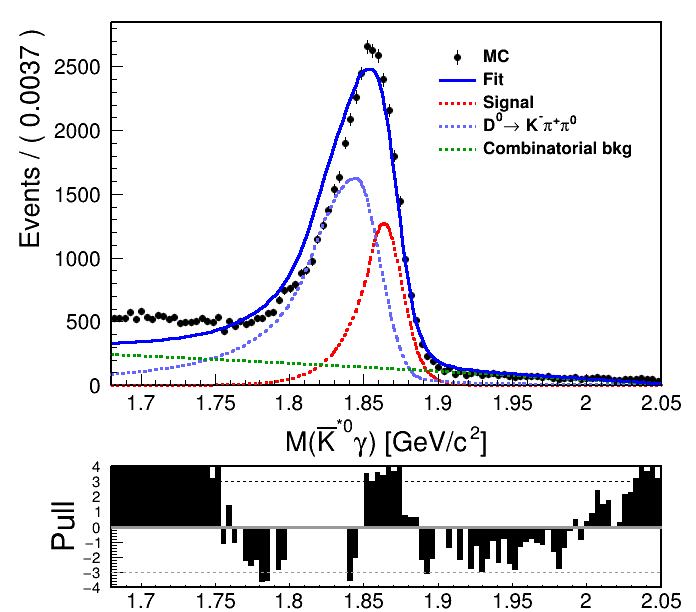

In [124]:
canv = ROOT.TCanvas("Canvas", "Canvas", 700, 640)

xlow = ctypes.c_double()
ylow = ctypes.c_double()
xup = ctypes.c_double()
yup = ctypes.c_double()

canv.GetPad(0).GetPadPar(xlow, ylow, xup, yup)
canv.Divide(1,2)

xlow = xlow.value
ylow = ylow.value
xup = xup.value
yup = yup.value

upPad = canv.GetPad(1)
upPad.SetPad(xlow, ylow+0.25*(yup-ylow),xup,yup)

dwPad = canv.GetPad(2)
dwPad.SetPad(xlow, ylow,xup,ylow+0.25*(yup-ylow))

    # r = sig.fitTo(data,NumCPU=12, Range=(1.84,1.89))
# r = sig_xy_model.fitTo(data,NumCPU=12, Range=(1.70,1.98))
# r = extended_model.fitTo(data,NumCPU=12, Extended=ROOT.kTRUE)
r = extended_model.fitTo(data,NumCPU=12, Extended=ROOT.kTRUE,PrintLevel=-1, Save=1,SumW2Error=True,Strategy=2)

r.Print()
canv.cd(1) 
#     frame = x.frame(Title="D^{0} #rightarrow #bar{K}^{*0} #pi^{0}")
frame = x.frame(Title=" ")

data.plotOn(frame,Name = "data1", XErrorSize=0)

# sig_xy_model.plotOn(frame,Components=mass_sig, ProjWData=data, Name="fitting")
extended_model.plotOn(frame, Name="fitx_sig", Components=x_sig_model, LineStyle=ROOT.kDashed, LineColor='r')
# extended_model.plotOn(frame, Name="fitx_bkg", Components=ROOT.RooArgSet(x_bkg1_model,x_bkg2_model), LineStyle=ROOT.kDashed, LineColor=ROOT.kGreen+2)
extended_model.plotOn(frame, Name="fitx_bkg1", Components=x_bkg1_model, LineStyle=ROOT.kDashed, LineColor=593)
extended_model.plotOn(frame, Name="fitx_bkg2", Components=x_bkg2_model, LineStyle=ROOT.kDashed, LineColor=ROOT.kGreen+2)
# extended_model.plotOn(frame, Name="fitx_bkg3", Components=x_bkg3_model, LineStyle=ROOT.kDashed, LineColor=ROOT.kGreen+10)



# extended_model.plotOn(frame, Name="fitx1", Components=x_bkg2_model, LineStyle=ROOT.kDashed, LineColor=593)

# extended_model.plotOn(frame, Name="fitx2", Components=x_sig_3, LineStyle=ROOT.kDashed, LineColor='r')
#sig_xy_model.plotOn(frame, Name="fitx3", Components=sig3, LineStyle=ROOT.kDashed, LineColor=593)

extended_model.plotOn(frame,Name="fitting")
frame.Draw("PE")

    # sig.paramOn(frame)
frame.GetXaxis().CenterTitle(True)

    

leg1 = ROOT.TLegend(0.62, 0.65, 0.92, 0.9)
# leg1.SetFillColor(ROOT.kWhite)
leg1.SetFillColor(0)

    # leg1.SetHeader("The Legend title","C")
leg1.AddEntry("data1", "MC", "PE")
leg1.AddEntry("fitting", "Fit", "l")
leg1.AddEntry("fitx_sig", "Signal", "l")
leg1.AddEntry("fitx_bkg1", "D^{0}#rightarrow K^{-}#pi^{+}#pi^{0}", "l")
leg1.AddEntry("fitx_bkg2", "Combinatorial bkg", "l")
# leg1.AddEntry("fitx_bkg3", "bkg3", "l")

# leg1.SetTextSize(0.05)
# leg1.SetTextAlign(13)

leg1.SetBorderSize(0)
leg1.Draw()

hpull = frame.pullHist()
hpull.SetFillStyle(1001)
hpull.SetFillColor(1);
for i in range(0,hpull.GetN()):#(int i=0;i<hpull.GetN();++i): 
    hpull.SetPointError(i,0.0,0.0,0.0,0.0)
    # pullplot = x.frame(Title(" "))
pullplot = x.frame()
pullplot.SetTitle("")
pullplot.addPlotable(hpull,"BE")
    # pullplot.addPlotable(hpull,"PE")

pullplot.SetYTitle("Pull")
pullplot.GetXaxis().SetTitleSize(0)
pullplot.GetYaxis().SetTitleSize(0.22)
pullplot.GetYaxis().CenterTitle(True)
pullplot.GetYaxis().SetTitleOffset(0.2)
pullplot.SetMinimum(-4.)
pullplot.SetMaximum(4.)
pullplot.GetXaxis().SetLabelSize(0.15)
pullplot.GetYaxis().SetLabelSize(0.105)
canv.cd(2)
pullplot.Draw()

xmin1 = ctypes.c_double(1.68)
xmax1 = ctypes.c_double(2.05)
    # xmin1 = 0.1
    # xmax1 = 0.18
line = ROOT.TLine(xmin1,0.0,xmax1,0.0)
line1 = ROOT.TLine(xmin1,3.0,xmax1,3.0)
line2 = ROOT.TLine(xmin1,-3.0,xmax1,-3.0)

line.SetLineColor(ROOT.kGray+1)
line.SetLineWidth(3)
line1.SetLineColor(ROOT.kBlack)
line2.SetLineColor(ROOT.kGray+1)
line1.SetLineStyle(2)
line2.SetLineStyle(2)
line.Draw("SAME")
line1.Draw("SAME")
line2.Draw("SAME")

canv.Update()

canv.Draw()
canv.SaveAs(file1_name)
